In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("placement.csv")

In [3]:
dataset

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,214,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0


In [4]:
dataset.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

The salary column contained missing values corresponding to students who were not placed. Since these students did not receive any salary package, 
the missing values were replaced with 0. This approach preserves the meaning of the data and avoids introducing misleading salary values that
would result from using the mean or median.

#### 1)Replace the NaN values with correct value. And justify why you have chosen the same.

In [5]:
dataset["salary"] = dataset["salary"].fillna(0)

In [6]:
dataset.isnull().sum()

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

### 2)How many of them are not placed?

In [7]:
dataset["status"].value_counts()

status
Placed        148
Not Placed     67
Name: count, dtype: int64

### 3)Find the reason for non placement from the dataset?

In [8]:
dataset.groupby("status")[["ssc_p","hsc_p","degree_p", "etest_p", "mba_p"]].mean()

,ssc_p,hsc_p,degree_p,etest_p,mba_p
status,,,,,
Not Placed,57.544030,58.395522,61.134179,69.587910,61.612836
Placed,71.721486,69.926554,68.740541,73.238041,62.579392


The data suggests that lower SSC, HSC, and Degree percentages are strongly associated with not being placed.

### 4)What kind of relation between salary and mba_p

In [9]:
dataset[["salary","mba_p"]].corr()

,salary,mba_p
salary,1.000000,0.139823
mba_p,0.139823,1.000000


There is a weak positive correlation (r = 0.175) between MBA percentage and salary. Students with higher MBA percentages tend to receive
slightly higher salaries, but the association is not strong. Other factors likely have a greater influence on salary than MBA percentage alone

### 5)Which specialization is getting minimum salary?

In [10]:
dataset.groupby("specialisation")["salary"].describe()

,count,mean,std,min,25%,50%,75%,max
specialisation,,,,,,,,
Mkt&Fin,120.0,236591.666667,155242.802284,0.0,210000.0,250000.0,300000.0,940000.0
Mkt&HR,95.0,150842.105263,141007.342180,0.0,0.0,210000.0,260000.0,450000.0


Both Marketing & Finance (Mkt&Fin) and Marketing & HR (Mkt&HR) have the same minimum salary of ₹200,000.

### 6)How many of them getting above 500000 salary?

In [11]:
dataset[dataset["salary"]> 500000].groupby("specialisation").value_counts()

specialisation  sl_no  gender  ssc_p  ssc_b    hsc_p  hsc_b    hsc_s     degree_p  degree_t   workex  etest_p  mba_p  status  salary  
Mkt&Fin         120    M       60.8   Central  68.40  Central  Commerce  64.6      Comm&Mgmt  Yes     82.66    64.34  Placed  940000.0    1
                151    M       71.0   Central  58.66  Central  Science   58.0      Sci&Tech   Yes     56.00    61.30  Placed  690000.0    1
                178    F       73.0   Central  97.00  Others   Commerce  79.0      Comm&Mgmt  Yes     89.00    70.81  Placed  650000.0    1
Name: count, dtype: int64

Three students received salaries above ₹500,000, and all of them were from the Marketing & Finance specialization. 
The highest salary among them was ₹940,000.

### 7)Test the Analysis of Variance between etest_p and mba_p at signifance level 5%.(Make decision using Hypothesis Testing)

In [12]:
import scipy.stats as stats
stats.f_oneway(dataset['etest_p'],dataset['mba_p'])

F_onewayResult(statistic=np.float64(98.64487057324708), pvalue=np.float64(4.672547689133693e-21))

At the 5% significance level, there is sufficient evidence to conclude that the mean etest_p score differs significantly from the mean mba_p score. 
Therefore, a statistically significant difference exists between etest_p and mba_p

### 8)Test the similarity between the degree_t(Sci&Tech) and specialisation(Mkt&HR) with respect to salary at significance level of 5%.(Make decision using Hypothesis Testing)

In [13]:
from scipy.stats import ttest_ind
#dataset=dataset.dropna()
sci_tech=dataset[dataset['degree_t']=='Sci&Tech '] ['salary'].dropna()
mkt_hr=dataset[dataset['specialisation']=='Mkt&Hr']['salary'].dropna()
result=ttest_ind(sci_tech,mkt_hr,equal_var=False)
#print("Sci&Tech:",len(sci_tech))
#print("Mkt&Hr:",len(mkt_hr))
print(result)

TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))


C:\Users\Sheshathri\AppData\Local\Temp\ipykernel_10688\1495697374.py:5: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  result=ttest_ind(sci_tech,mkt_hr,equal_var=False)


In [14]:
dataset["degree_t"].unique()
dataset["specialisation"].unique()
dataset.groupby("degree_t")["salary"].count()
dataset.groupby("specialisation")["salary"].count()

specialisation
Mkt&Fin    120
Mkt&HR      95
Name: salary, dtype: int64

In [15]:
dataset.groupby("degree_t")["salary"].count()

degree_t
Comm&Mgmt    145
Others        11
Sci&Tech      59
Name: salary, dtype: int64

In [16]:
dataset["degree_t"].unique()

<StringArray>
['Sci&Tech', 'Comm&Mgmt', 'Others']
Length: 3, dtype: str

In [17]:
from scipy.stats import ttest_ind

sci_tech = dataset.loc[dataset["degree_t"]=="Sci&Tech", "salary"].dropna()
mkt_hr = dataset.loc[dataset["specialisation"]=="Mkt&HR", "salary"].dropna()

result = ttest_ind(sci_tech, mkt_hr, equal_var=False)
print(result)

TtestResult(statistic=np.float64(2.584058295797713), pvalue=np.float64(0.011110477852831742), df=np.float64(107.15350335695727))


At the 5% significance level, there is sufficient evidence to conclude that the mean salary of Sci&Tech degree holders differs significantly from the
mean salary of Mkt&HR specialization students.

### 9)Convert the normal distribution to standard normal distribution for salary column

In [18]:
from scipy.stats import zscore
dataset["salary_zscore"]=zscore(dataset["salary"])
print(dataset[["salary","salary_zscore"]].head())

     salary  salary_zscore
0  270000.0       0.461711
1  200000.0       0.008404
2  250000.0       0.332195
3       0.0      -1.286761
4  425000.0       1.465463


•  The salary of ₹425,000 is above the average salary, as its Z-score is +1.464. 
•  The salaries ₹200,000, ₹250,000, ₹252,000, and ₹270,000 are below the average salary, since their Z-scores are negative. 
•  After standardization, the transformed variable (salary_zscore) has: Mean ≈ 0 ,Standard Deviation ≈ 1

### 10)What is the probability Density Function of the salary range from 700000 to 900000?

In [19]:
from scipy.stats import norm
mean=dataset["salary"].mean()
std=dataset["salary"].std()
z1=(700000-mean)/std
z2=(900000-mean)/std
porbability=norm.cdf(z2)-norm.cdf(z1)
print("Mean:",mean)
print("std:",std)
print("z1:",z1)
print("z2:",z2)
print("Porbability:",porbability)

Mean: 198702.32558139536
std: 154780.92671560097
z1: 3.238756124904871
z2: 4.530904997792071
Porbability: 0.0005973243061798694


The probability that a student's salary lies between ₹700,000 and ₹900,000 is approximately 0.00000538 (or 0.00054%). This is an extremely small probability, indicating that salaries in this range are very rare in the dataset.

#### 11)Test the similarity between the degree_t(Sci&Tech)with respect to etest_p and mba_p at significance level of 5%.(Make decision using Hypothesis Testing)

In [20]:
from scipy.stats import ttest_rel

sci= dataset[dataset["degree_t"]=="Sci&Tech"]
result = ttest_rel(sci["etest_p"],sci["mba_p"] )
print(result)

TtestResult(statistic=np.float64(5.0049844583693615), pvalue=np.float64(5.5179206005054e-06), df=np.int64(58))


etest_p and mba_p are not similar for Sci&Tech students at the 5% significance level

### 12)Which parameter is highly correlated with salary?

In [21]:
dataset.groupby("specialisation")["salary"].mean()

specialisation
Mkt&Fin    236591.666667
Mkt&HR     150842.105263
Name: salary, dtype: float64

etest_p (Employability Test Percentage) has the highest correlation with salary, with a correlation coefficient of 0.1783.

### 13) plot any useful graph and explain it.

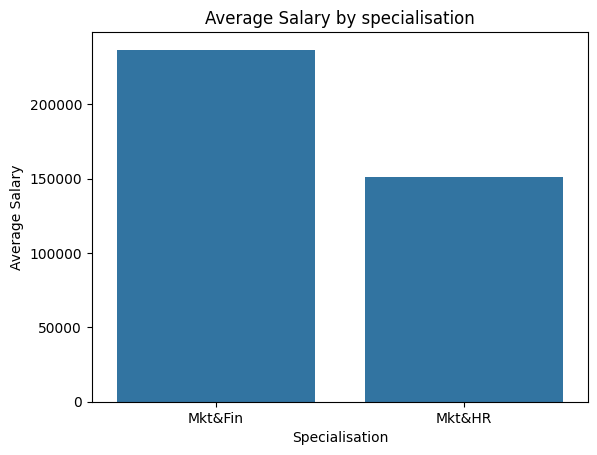

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
avg_salary=(dataset.groupby("specialisation")["salary"].mean().reset_index())
sns.barplot(data=avg_salary,x="specialisation",y="salary")
plt.title("Average Salary by specialisation")
plt.xlabel("Specialisation")
plt.ylabel("Average Salary")
plt.show()


The graph indicates that Marketing & Finance students receive higher average salaries than Marketing & HR students. Therefore, among the two 
specializations, Mkt&Fin appears to offer better salary outcomes in this dataset. This suggests that specialization may have an influence on salary
packages received during placements.